In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Statystyka - raport 
Karol Garbaczewski, Adam Freń

## Cel raportu 
Celem niniejszego raportu jest analiza danych o spóźnieniach pociągów spółki PKP Intercity z lat 2019 oraz 2020 zebranych ze strony: [link](https://dane.utk.gov.pl/). Zamierzamy porównać jaką proporcje w każdej stacji stanowią spóźnione pociągi oraz jak sie ma stosunek spóźnionych pociągów z jednej stacji do wszystkich zatrzymań pociągów. Będziemy korzystać ze średnich danych rocznych. 

Zamierzamy również wykorzystać dane z GUS'u dotyczące ludności miast i miejscowości w Polsce do tego aby sprawdzić czy dane z małych miast (>100 tyś. mieszkańców) różnią się znacząco od danych z dużych miast (<100 tyś. mieszkańców). Spróbujemy znaleźć miasta które przez dwa lata były w ogonach rozkładów. 

## Wstęp 
### Dane
Dane **Urzędu Transportu Kolejowego** które będziemy analizować obejmują:
- liczbę zatrzymań pociągów opóźnionych od 6min w zależności od konkretnego miesiąca,
- liczbę zatrzymań wszystkich pociągów w zależności od konkretnego miesiąca,
- wielkość opóźnień (w minutach) dla pociągów opóźnionych od 6min,
- procent opóźnionych zatrzymań na stacjach (rocznie),
- średni czas opóźnień na stacji dla pociągów opóźnionych od 6min.

Dodatkowo połączyliśmy dane PKP z danymi z GUS'u wiążąc wielkość spóźnień z wielkościom populacji miasta. Niestety połączenie tych dwóch baz danych było skomplikowanym zadaniem i stacji przypisanych do konkretnych miejscowości jest ok. 60%.  Na potrzeby naszej analizy będziemy korzystać z tego pomniejszonego zbioru danych, jednakże zdajemy sobie sprawę, że analiza tego typu danych może być wybrakowana. Dzięki temu możemy podzielić nasze stacje na te które należą do dużych miast (+100k mieszkańców) oraz należące do mniejszych miejscowości (<100k mieszkańców). 

### Co chcemy zbadać?
Chcemy porównać zbióry danych z 2019, 2020 dla dużych miast i małych miejscowości pod kątem:
-  prawdopodobieństwa spóźnienia pociągu (prawd_na_spoznienie_kazda_stacja_oddzielnie w prawd_pociagow)
- średnie roczne opóźnienie przypadające na jeden opóźniony pociąg (roczna_srednia_ile_spoznienia_na_pociag)
    policzmy do tego statystyki: 
    - odchylenie standardowe, 
    - kurtoza, 
    - skosność, 
- histogramy tych cech, oraz wykresy pudelkowe,
- sprawdzimy czy niektóre stacje zarówno w 2020 i 2019 roku znajdowały się w ogonach rozkładów,
- postaramy się odpowiedzieć na pytanie w jaki sposób uniknąć spóźnień.

Bedziemy korzystać z średnich miesięcznych danych o spóźnieniach dzięki czemu bedą one mniej podatne na fluktuacje oraz nawet dla mniejszych stacji będą zazwyczaj niezerowe. 

### Wzory z których korzystamy:
- średnia arytmetyczna:
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

gdzie $ x_{1}, x_{2}, ..., x_{n} $ to nasze obserwacje, a $ n $ liczebność próby.
- odchylenie standardowe:
$$s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}$$
- skośność:
$$S = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$
- kurtoza:
$$K = \left[ \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 \right] - \frac{3(n-1)^2}{(n-2)(n-3)}$$
- mediana:

$$ Me = x_{\frac{n+1}{2}}, \quad Me = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2}$$
 w zależności od wiekości próby. 



## Prawdopodobieństwo spóźnienia dla konkretnej stacji

W tej części przeanalizujemy jak wygląda rozkład dwóch prawdopodobieństwa spóźnienia pociągu, do tego celu policzyliśmy liczbę opóźnień w ciągu miesiąca i podzieliśmy przez liczbę wszystkich zatrzymań pociągów, następnie policzyliśmy średnią dla całego roku dla każdej konkretnej stacji. 


In [ ]:
prawd_pociagow_2019 = pd.read_excel('wyniki\\prawd_pociagow_2019.xlsx', index_col=0)
prawd_pociagow_2020 = pd.read_excel('wyniki\\prawd_pociagow_2020.xlsx', index_col=0)

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\karol\AppData\Local\Temp\ipykernel_6364\2667068013.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  prawd_pociagow_2019 = pd.read_excel('wyniki\prawd_pociagow_2019.xlsx', index_col=0)
C:\Users\karol\AppData\Local\Temp\ipykernel_6364\2667068013.py:2: SyntaxWarning: "\p" is 

In [174]:
prawd_pociagow_2019 = prawd_pociagow_2019.sort_values(by='prawd_na_spoznienie_kazda_stacja_oddzielnie', ascending=False)
prawd_pociagow_2020 = prawd_pociagow_2020.sort_values(by='prawd_na_spoznienie_kazda_stacja_oddzielnie', ascending=False)

### Histogram 

297
1091


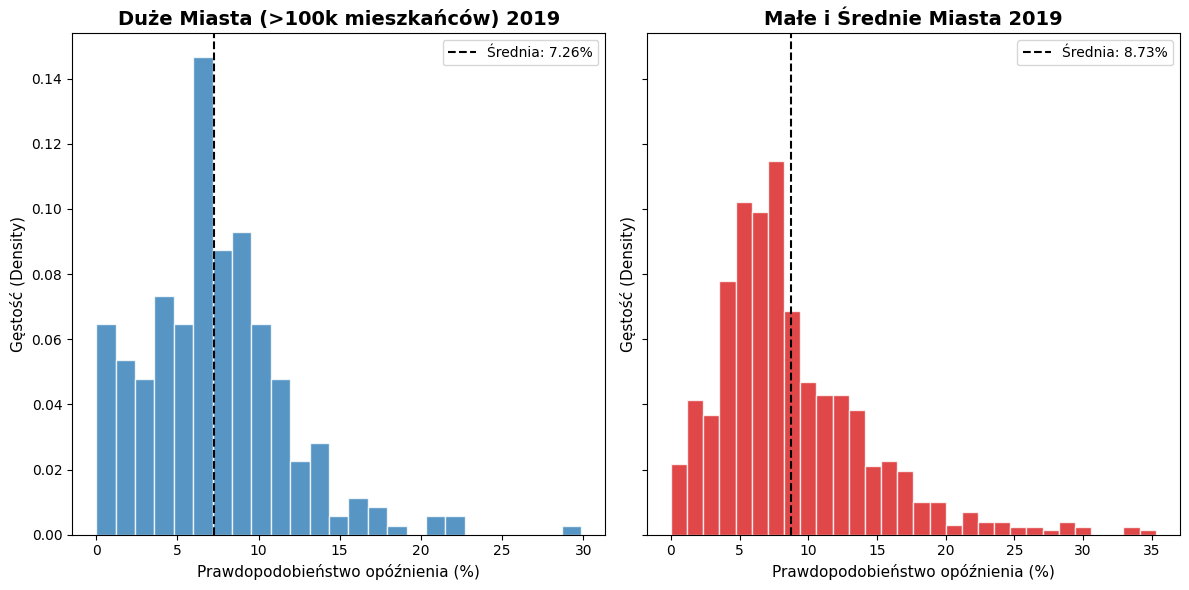

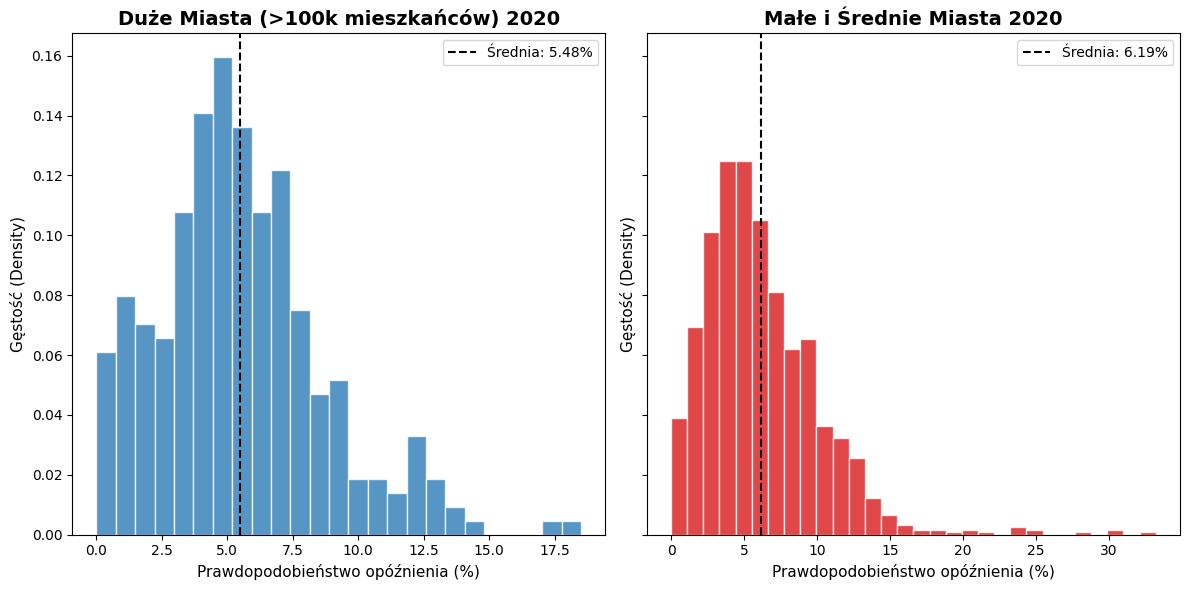

In [176]:
#2019
mask = prawd_pociagow_2019['Ludność'] > 100000
duze_miasta_2019 = prawd_pociagow_2019[mask]
male_miasta_2019 = prawd_pociagow_2019[~mask]

duze_miasta_spoz_2019 = duze_miasta_2019['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
male_miasta_spoz_2019 = male_miasta_2019['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
print(len(duze_miasta_spoz_2019))
print(len(male_miasta_spoz_2019))
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(duze_miasta_spoz_2019, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0].set_title('Duże Miasta (>100k mieszkańców) 2019', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[0].set_ylabel('Gęstość (Density)', fontsize=11)

ax[1].hist(male_miasta_spoz_2019, bins=30, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1].set_title('Małe i Średnie Miasta 2019', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[1].set_ylabel('Gęstość (Density)', fontsize=11)

ax[0].axvline(duze_miasta_spoz_2019.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_spoz_2019.mean():.2f}%')
ax[1].axvline(male_miasta_spoz_2019.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_spoz_2019.mean():.2f}%')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

# 2020
mask = prawd_pociagow_2020['Ludność'] > 100000
duze_miasta_2020 = prawd_pociagow_2020[mask]
male_miasta_2020 = prawd_pociagow_2020[~mask]

duze_miasta_spoz_2020 = duze_miasta_2020['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
male_miasta_spoz_2020 = male_miasta_2020['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
#print(len(duze_miasta_spoz_2020))
#print(len(male_miasta_spoz_2020))
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(duze_miasta_spoz_2020, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0].set_title('Duże Miasta (>100k mieszkańców) 2020', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[0].set_ylabel('Gęstość (Density)', fontsize=11)

ax[1].hist(male_miasta_spoz_2020, bins=30, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1].set_title('Małe i Średnie Miasta 2020', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[1].set_ylabel('Gęstość (Density)', fontsize=11)

ax[0].axvline(duze_miasta_spoz_2020.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_spoz_2020.mean():.2f}%')
ax[1].axvline(male_miasta_spoz_2020.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_spoz_2020.mean():.2f}%')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()
# Spoźnienia na stacji 

#### Interpretacja:
Histogramy pokazują, że w 2019 roku prawdopodobieństwo opóźnienia w dużych miastach było niższe (7,26%) niż w mniejszych ośrodkach (8,73%). Rozkłady dla małych miast charakteryzują się wyraźnie „cięższymi ogonami”, co wynika z mniejszej liczby kursujących pociągów – w takich warunkach nawet kilka opóźnionych składów drastycznie podnosi wynik danej stacji. 

W roku 2020 zaobserwowano istotną poprawę punktualności: zakres danych dla dużych miast zawęził się z 0–29% do 0–18%, a średnie dla obu grup uległy obniżeniu. Wszystkie analizowane rozkłady cechują się asymetrią prawostronną, przy czym w roku pandemicznym (2020) „ogony” stały się lżejsze, co świadczy o większej stabilności systemu przy mniejszym obciążeniu ruchu.


### Statystyki
Policzmy teraz statystyki dla tego rozkładu: odchylenie standardowe, skośność, kurtozę, medianę oraz kwantyle.

In [177]:
# Łączymy wyniki describe() w poziomie (axis=1)

extra_2019 = pd.Series({
    'Skewness': duze_miasta_spoz_2019.skew(),
    "Kurtosis": duze_miasta_spoz_2019.kurtosis()})
extra_2020 = pd.Series({
    'Skewness': duze_miasta_spoz_2020.skew(),
    "Kurtosis": duze_miasta_spoz_2020.kurtosis()})
duze_miasta_2019_stats = pd.concat([duze_miasta_spoz_2019.describe(), extra_2019])
duze_miasta_2020_stats = pd.concat([duze_miasta_spoz_2020.describe(), extra_2020])
porownanie = pd.concat([
    duze_miasta_2019_stats, 
    duze_miasta_2020_stats
], axis=1)

# Nadajemy własne nazwy kolumnom, żeby wiedzieć, który rok jest który
porownanie.columns = ['2019 (Duże miasta)', '2020 (Duże miasta)']

print(porownanie)
print("")
extra_2019 = pd.Series({
    'Skewness': male_miasta_spoz_2019.skew(),
    "Kurtosis": male_miasta_spoz_2019.kurtosis()})
extra_2020 = pd.Series({
    'Skewness': male_miasta_spoz_2020.skew(),
    "Kurtosis": male_miasta_spoz_2020.kurtosis()})
male_miasta_2019_stats = pd.concat([male_miasta_spoz_2019.describe(), extra_2019]) 
male_miasta_2020_stats = pd.concat([male_miasta_spoz_2020.describe(), extra_2020])
porownanie_male = pd.concat([  male_miasta_2019_stats, male_miasta_2020_stats], axis=1)
porownanie_male.columns = ['2019 (Małe i średnie miasta)', '2020 (Małe i średnie miasta)']
print(porownanie_male)

          2019 (Duże miasta)  2020 (Duże miasta)
count             297.000000          288.000000
mean                7.259211            5.476590
std                 4.365427            3.197537
min                 0.000000            0.000000
25%                 4.317678            3.429624
50%                 6.779985            5.053579
75%                 9.535304            7.146237
max                29.869213           18.507085
Skewness            1.012769            0.841641
Kurtosis            2.706796            1.117613

          2019 (Małe i średnie miasta)  2020 (Małe i średnie miasta)
count                      1091.000000                   1092.000000
mean                          8.725471                      6.191307
std                           5.510317                      4.012397
min                           0.000000                      0.000000
25%                           5.114871                      3.487477
50%                           7.548920        

#### Interpretacja 

Statystyki potwierdzają wnioski z histogramu. Małe miasta mają wyższe rozproszenie danych, co odzwierciedla wyższe odchylenie standardowe w tej grupie. Dodatnie wartości skośności dla wszystkich zbiorów jednoznacznie wskazują na asymetrię prawostronną. Ponieważ Pandas wykorzystuje definicję kurtozy nadmiarowej według Fishera (gdzie dla rozkładu normalnego $K=0$), uzyskane wyniki potwierdzają, że badane rozkłady mają istotnie "cięższe ogony" niż rozkład Gaussa. 

Porównując dane rok do roku, zauważalna jest istotna anomalia w grupie mniejszych ośrodków: pomimo spadku średniej wartości opóźnień, odnotowano tam wyraźny wzrost kurtozy (z 3.00 do 6.12) oraz skośności. Oznacza to, że choć ogólna punktualność uległa poprawie, nie wyeliminowano problemu skrajnych przypadków – na wybranych stacjach prawdopodobieństwo spóźnienia nadal utrzymywało się na ekstremalnym poziomie (ok. 30%).

W 2020 roku zarejestrowano spadek łącznej liczby zatrzymań na stacjach o 1 295 336 (ok. 4,6%), co wynikało z ograniczeń wprowadzonych w trakcie pandemii COVID-19. Zmniejszenie obciążenia infrastruktury bezpośrednio przyczyniło się do redukcji opóźnień w większości węzłów, jednak nie zniwelowało opóźnień o charakterze systemowym na najbardziej problematycznych odcinkach sieci. 

#### Box-plot 

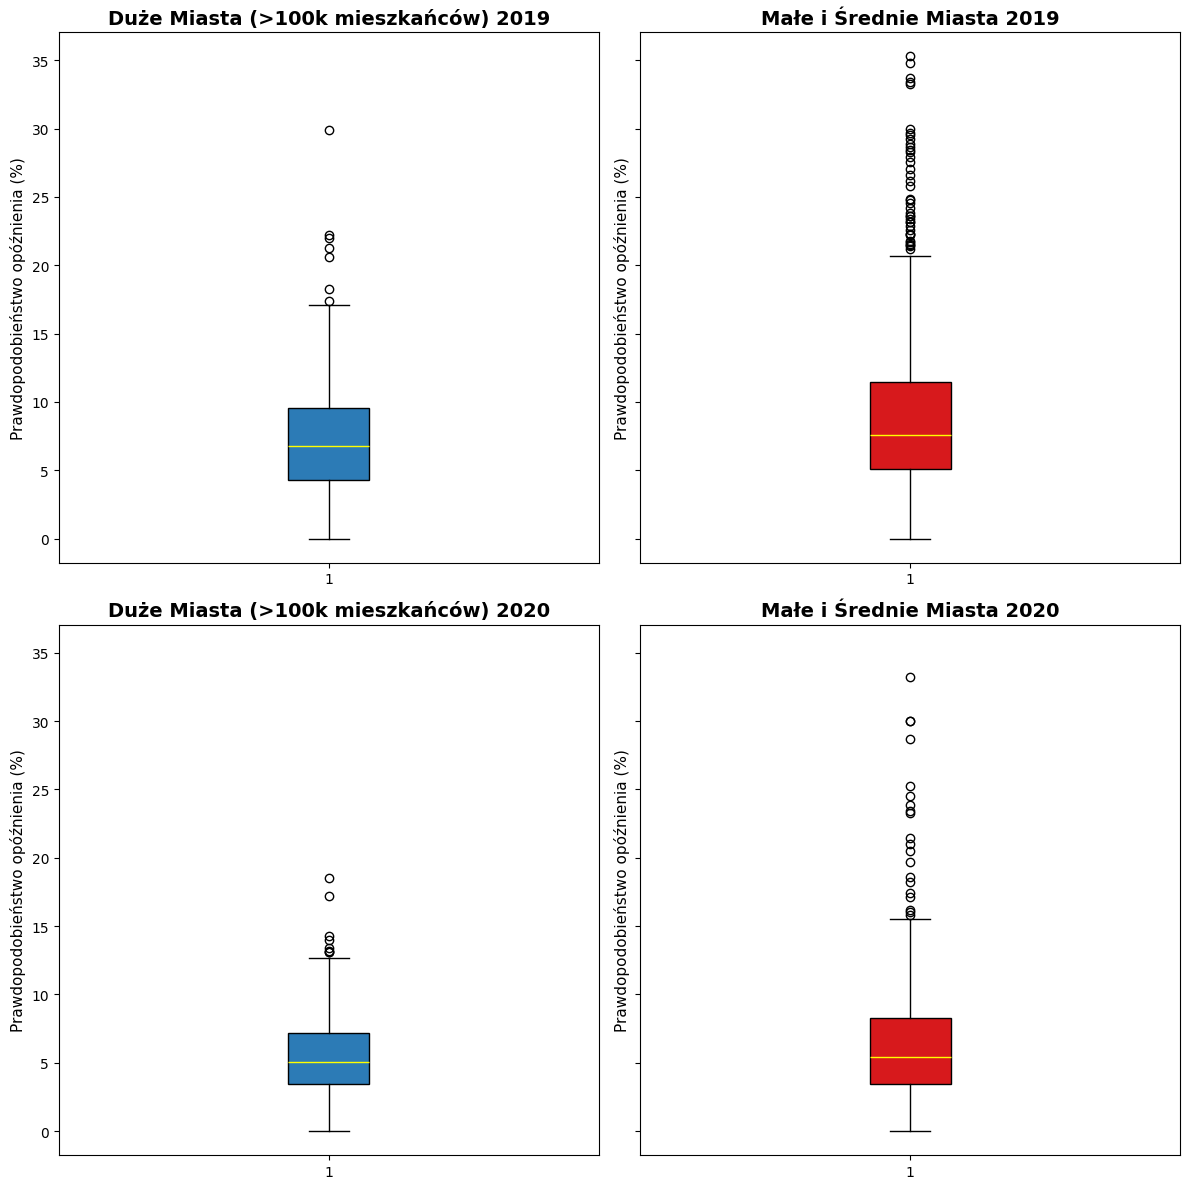

In [178]:
fig, ax = plt.subplots(2,2, figsize=(12,12), sharey=True)
ax[0,0].boxplot(duze_miasta_spoz_2019, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[0,0].set_title('Duże Miasta (>100k mieszkańców) 2019', fontsize=14, fontweight='bold')
ax[0,0].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[0,1].boxplot(male_miasta_spoz_2019, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[0,1].set_title('Małe i Średnie Miasta 2019', fontsize=14, fontweight='bold')
ax[0,1].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[1,0].boxplot(duze_miasta_spoz_2020, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[1,0].set_title('Duże Miasta (>100k mieszkańców) 2020', fontsize=14, fontweight='bold')
ax[1,0].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[1,1].boxplot(male_miasta_spoz_2020, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[1,1].set_title('Małe i Średnie Miasta 2020', fontsize=14, fontweight='bold')
ax[1,1].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
plt.tight_layout()
plt.show()

#### Interpretacja 
Z box-plotu możemy wyciągnąć podobne wnioski jak z histogramu. Wykresy pudełkowe potwierdzają ogólny spadek prawdopodobieństwa opóźnień w 2020 roku, objawiający się obniżeniem mediany oraz wyraźnym skróceniem "pudełek" i górnych wąsów, co świadczy o większej przewidywalności ruchu.

Mimo to, w grupie małych i średnich miast wciąż widoczna jest duża liczba wartości odstających, co koresponduje z wysoką kurtozą i wskazuje na punkty o chronicznie niskiej punktualności. Zjawisko to jest znacznie mniej dotkliwe w dużych miastach, gdzie zakres danych w roku pandemicznym uległ radykalnemu zawężeniu.

### Analiza ogonów

Spróbujemy znaleźć zależności między miejscowościami z ogona rozkładu. 

In [179]:
ogon_2019 = prawd_pociagow_2019.iloc[[ i for i in range(15) ]][["prawd_na_spoznienie_kazda_stacja_oddzielnie"]]
ogon_2020 = prawd_pociagow_2020.iloc[[ i for i in range(15) ]][["prawd_na_spoznienie_kazda_stacja_oddzielnie"]]
print(prawd_pociagow_2019.iloc[[ i for i in range(15) ]][["prawd_na_spoznienie_kazda_stacja_oddzielnie"]])

                        prawd_na_spoznienie_kazda_stacja_oddzielnie
Tereszpol Biłgorajski                                      0.352826
Zduńska Wola Karsznice                                     0.348023
Inowrocław Rąbinek                                         0.337028
Szamotuły                                                  0.334089
Biłgoraj                                                   0.333014
Wronki                                                     0.299522
Poznań Wola                                                0.298692
Zwierzyniec                                                0.296720
Rokietnica                                                 0.295632
Nowa Ruda Przedmieście                                     0.292136
Nowa Ruda Zdrojowisko                                      0.288806
Radzyń Podlaski                                            0.286561
Dobiegniew                                                 0.284213
Głuszyca                                        

In [180]:
print(prawd_pociagow_2020.iloc[[ i for i in range(15) ]][["prawd_na_spoznienie_kazda_stacja_oddzielnie"]])

                       prawd_na_spoznienie_kazda_stacja_oddzielnie
Dobiegniew                                                0.332064
Choszczno                                                 0.300340
Bierzwnik                                                 0.300044
Szamotuły                                                 0.286713
Dorohusk                                                  0.252586
Wronki                                                    0.245118
Dolice                                                    0.238938
Rokietnica                                                0.234125
Nałęczów                                                  0.233143
Puławy Miasto                                             0.214793
Tereszpol Biłgorajski                                     0.210213
Zaklików                                                  0.205256
Witkowo Pyrzyckie                                         0.196952
Zwierzyniec                                               0.18

In [181]:
stacje_2019 = set(ogon_2019.index) 
stacje_2020 = set(ogon_2020.index)
powtarzajace_sie = stacje_2019.intersection(stacje_2020)
print("Stacje, które pojawiły się w obu latach:")
print(powtarzajace_sie)

Stacje, które pojawiły się w obu latach:
{'Rokietnica', 'Zwierzyniec', 'Wronki', 'Szamotuły', 'Dobiegniew', 'Tereszpol Biłgorajski'}


#### Interpretacja 
Miasta które się powtarzają w obu latach nie są przypadkowe:
- Szamotuły, Wronki, Rokietnica, Dobiegniew - Leżą na lini E59 (Poznań - Szczecin)
- Tereszpol Biłograjski, Biłgoraj, Zwierzyniec - leżą na lini 66 (Zwierzyniec - Biłograj) 

Dodatkowo obie grupy stacji kolejowych są blisko siebie geograficznie co pokazuje, że są wąskie gardła polskiej lini kolejowej. Linia 66 jest jednotorowa oraz nie zelektryfikowana co może być przyczyną notorycznych spóźnień. Natomiast w latach 2019-2020 linia E59 była modernizowana, wymieniano sieć trakcyjną itd. co powodowało ruch wachadłowy i przy dużym natężeniu ruchu rozprzestrzeniało opóźnienia tworząc w pewnym sensie efekt domina. 


### Średnia wielkość opóźnienia w minutach
Bierzemy dla każdej stacji i każdego miesiąca sumę minut opóźnień następnie dzielimy przez liczbę opóźnionych pociągów, jeśli liczba opóźnionych pociągów jest równa 0 to dostajemy zero. 

In [190]:
duze_miasta_20 = pd.read_excel(r'wyniki\miasta_2020_wiecej_niz_100k.xlsx', index_col=0)
duze_miasta_20 = duze_miasta_20.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)
male_miasta_20 = pd.read_excel(r'wyniki\miasta_2020_mniej_niz_100k.xlsx', index_col=0)
male_miasta_20 = male_miasta_20.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)

duze_miasta_19 = pd.read_excel(r'wyniki\miasta_2019_wiecej_niz_100k.xlsx', index_col=0)
duze_miasta_19 = duze_miasta_19.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)
male_miasta_19 = pd.read_excel(r'wyniki\miasta_2019_mniej_niz_100k.xlsx', index_col=0)
male_miasta_19 = male_miasta_19.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)


duze_miasta_wielk_spoz_20=duze_miasta_20["roczna_srednia_ile_spoznienia_na_pociag"]
male_miasta_wielk_spoz_20=male_miasta_20["roczna_srednia_ile_spoznienia_na_pociag"]
duze_miasta_wielk_spoz_19=duze_miasta_19["roczna_srednia_ile_spoznienia_na_pociag"]
male_miasta_wielk_spoz_19=male_miasta_19["roczna_srednia_ile_spoznienia_na_pociag"]


## Średni czas opóźnienia
Do wyliczenia średniego czasu spóźnienia wykorzystaliśmy dane o sumie spóźnień  pociągów dla danego miesiąca z konkretnej stacji i podzieliliśmy je przez sumę spóźnionych pociągów. Policzyliśmy średnią dla każdej stacji. 

### Histogram

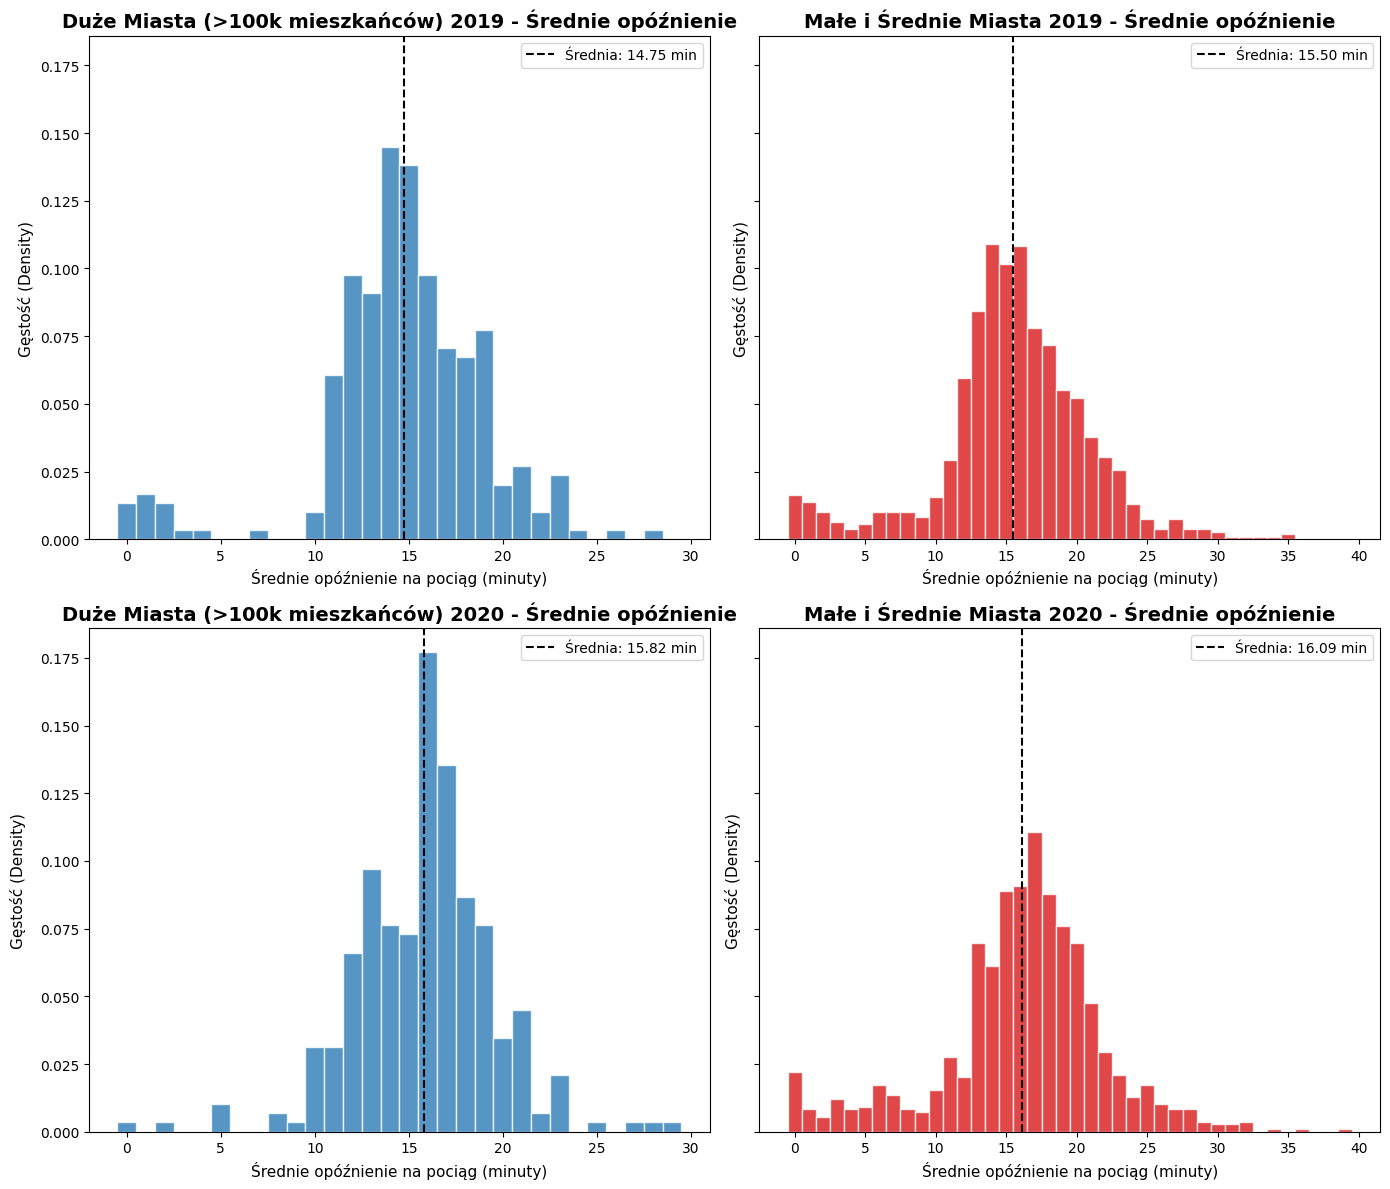

In [191]:
fig, ax = plt.subplots(2,2, figsize=(14,12), sharey=True)

bins = np.arange(min(duze_miasta_wielk_spoz_19), max(duze_miasta_wielk_spoz_20) +2) -0.5
ax[0,0].hist(duze_miasta_wielk_spoz_19, bins=bins, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0,0].set_title('Duże Miasta (>100k mieszkańców) 2019 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[0,0].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[0,0].set_ylabel('Gęstość (Density)', fontsize=11)
ax[0,0].axvline(duze_miasta_wielk_spoz_19.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_wielk_spoz_19.mean():.2f} min')
ax[0,0].legend()

bins = np.arange(min(male_miasta_wielk_spoz_19), max(male_miasta_wielk_spoz_20) +2) -0.5
ax[0,1].hist(male_miasta_wielk_spoz_19, bins=bins, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[0,1].set_title('Małe i Średnie Miasta 2019 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[0,1].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[0,1].set_ylabel('Gęstość (Density)', fontsize=11)
ax[0,1].axvline(male_miasta_wielk_spoz_19.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_wielk_spoz_19.mean():.2f} min')
ax[0,1].legend()

bins = np.arange(min(duze_miasta_wielk_spoz_20), max(duze_miasta_wielk_spoz_20) +2) -0.5
ax[1,0].hist(duze_miasta_wielk_spoz_20, bins=bins, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[1,0].set_title('Duże Miasta (>100k mieszkańców) 2020 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[1,0].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[1,0].set_ylabel('Gęstość (Density)', fontsize=11, labelpad=10)
ax[1,0].axvline(duze_miasta_wielk_spoz_20.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_wielk_spoz_20.mean():.2f} min')
ax[1,0].legend()

bins = np.arange(min(male_miasta_wielk_spoz_20), max(male_miasta_wielk_spoz_20) +2) -0.5
ax[1,1].hist(male_miasta_wielk_spoz_20, bins=bins, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1,1].set_title('Małe i Średnie Miasta 2020 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[1,1].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[1,1].set_ylabel('Gęstość (Density)', fontsize=11, labelpad=10)
ax[1,1].axvline(male_miasta_wielk_spoz_20.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_wielk_spoz_20.mean():.2f} min')
ax[1,1].legend()

plt.tight_layout()
plt.show()


#### Interpretacja

Średnie roczna wielkość spóźnienia pociągu w przypadku dużych miast oscyluje w okolicy 15min, w przypadku mniejszych miast oscyluje ok. 16 minut. Pomimo tego, że średnie wielkości spóżnienia są zbliżone dla wszystkich 4. wykresów to warto zauważyć, że ogony rozkładów znacznie szybciej zanikają dla dużych miast, szczególnie w roku 2020. 

Bardzo duży słupek przy wartościach 0 dla dużych miast w 2020 roku wynika z faktu, że niektóre stację nie są użytkowane pasażersko i mają niską liczbę pociągów przejeżdzającą przez stacje w całym roku. 

Utrzymanie szerszych ogonów w małych i średnich miastach sugeruje, że mimo ogólnego spadku liczby pociągów w pandemii, linie kolejowe pozostały bardziej podatne na długotrwałe zakłócenia ruchu. Histogram sugeruje, że częstotliwość skrajnych średnich opóźnień jest większa dla małych miast.

In [192]:
# Łączymy wyniki describe() w poziomie (axis=1)

duze_miasta_2019_extra = pd.Series({
    'Skewness': duze_miasta_wielk_spoz_19.skew(),
    "Kurtosis": duze_miasta_wielk_spoz_19.kurtosis()})
duze_miasta_2020_extra = pd.Series({
    'Skewness': duze_miasta_wielk_spoz_20.skew(),
    "Kurtosis": duze_miasta_wielk_spoz_20.kurtosis()})
duze_miasta_2019_stats = pd.concat([duze_miasta_wielk_spoz_19.describe(), duze_miasta_2019_extra])
duze_miasta_2020_stats = pd.concat([duze_miasta_wielk_spoz_20.describe(), duze_miasta_2020_extra])
porownanie = pd.concat([
    duze_miasta_2019_stats, 
    duze_miasta_2020_stats
], axis=1)

# Nadajemy własne nazwy kolumnom, żeby wiedzieć, który rok jest który
porownanie.columns = ['2019 (Duże miasta)', '2020 (Duże miasta)']

print(porownanie)
print("")
male_miasta_2019_extra = pd.Series({
    'Skewness': male_miasta_wielk_spoz_19.skew(),
    "Kurtosis": male_miasta_wielk_spoz_19.kurtosis()})
male_miasta_2020_extra = pd.Series({
    'Skewness': male_miasta_wielk_spoz_20.skew(),
    "Kurtosis": male_miasta_wielk_spoz_20.kurtosis()})
male_miasta_2019_stats = pd.concat([male_miasta_wielk_spoz_19.describe(), male_miasta_2019_extra]) 
male_miasta_2020_stats = pd.concat([male_miasta_wielk_spoz_20.describe(), male_miasta_2020_extra])
porownanie_male = pd.concat([  male_miasta_2019_stats, male_miasta_2020_stats], axis=1)
porownanie_male.columns = ['2019 (Małe i średnie miasta)', '2020 (Małe i średnie miasta)']
print(porownanie_male)

          2019 (Duże miasta)  2020 (Duże miasta)
count             297.000000          288.000000
mean               14.754209           15.822917
std                 4.390968            3.686291
min                 0.000000            0.000000
25%                13.000000           13.000000
50%                15.000000           16.000000
75%                17.000000           18.000000
max                28.000000           29.000000
Skewness           -0.979414           -0.265578
Kurtosis            2.897298            2.368180

          2019 (Małe i średnie miasta)  2020 (Małe i średnie miasta)
count                      1091.000000                   1092.000000
mean                         15.497709                     16.092491
std                           5.416484                      5.828881
min                           0.000000                      0.000000
25%                          13.000000                     14.000000
50%                          16.000000        

#### Interpretacja

Statystyki potwierdzają nam wnioski z histogramu. Oba zbiory danych charakteryzują się niewielką ujemną skośnością, co oznacza, że rozkłady są lewostronnie skośne (z dłuższą lewą stroną rozkładu). Dodatnia kurtoza nadmiarowa informuje nas natomiast, że ogony rozkładów są cięższe niż w przypadku rozkładu normalnego, co wiąże się z częstszym występowaniem wartości skrajnych. Warto zauważyć, że dane dla dużych miast są znacznie silniej skoncentrowane wokół średniej, co potwierdza niższa wartość odchylenia standardowego w porównaniu do mniejszych ośrodków. Średnia i mediana są zbliżone do siebie. 

### Box-plot 

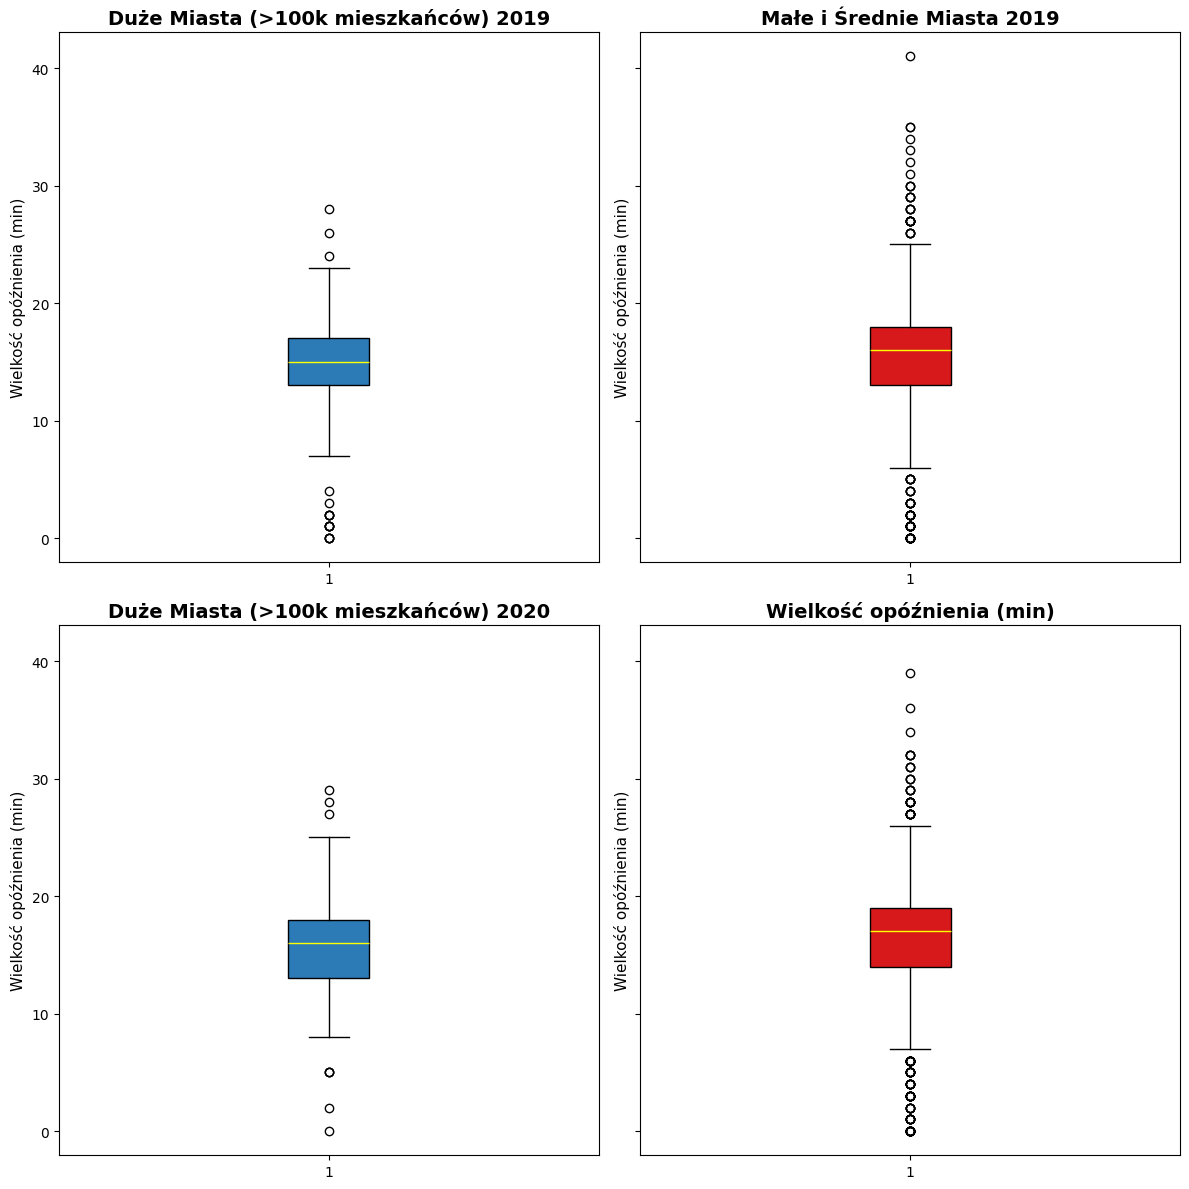

In [193]:
fig, ax = plt.subplots(2,2, figsize=(12,12), sharey=True)
ax[0,0].boxplot(duze_miasta_wielk_spoz_19, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[0,0].set_title('Duże Miasta (>100k mieszkańców) 2019', fontsize=14, fontweight='bold')
ax[0,0].set_ylabel('Wielkość opóźnienia (min)', fontsize=11)

ax[0,1].boxplot(male_miasta_wielk_spoz_19, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[0,1].set_title('Małe i Średnie Miasta 2019', fontsize=14, fontweight='bold')
ax[0,1].set_ylabel('Wielkość opóźnienia (min)', fontsize=11)

ax[1,0].boxplot(duze_miasta_wielk_spoz_20, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[1,0].set_title('Duże Miasta (>100k mieszkańców) 2020', fontsize=14, fontweight='bold')
ax[1,0].set_ylabel('Wielkość opóźnienia (min)', fontsize=11)

ax[1,1].boxplot(male_miasta_wielk_spoz_20, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[1,1].set_title('Wielkość opóźnienia (min)', fontsize=14, fontweight='bold')
ax[1,1].set_ylabel('Wielkość opóźnienia (min)', fontsize=11)
plt.tight_layout()
plt.show()

#### Interpretacja


Wykresy pudełkowe wskazują na dużą stabilność mediany opóźnień, która we wszystkich grupach utrzymuje się na zbliżonym poziomie około 16–17 minut. Zwraca uwagę obecność licznych wartości odstających (powyżej lub poniżej wąsów), szczególnie w małych i średnich miastach, co potwierdza nam grube ogony, które wskazują, że średnie opóźnienie w niektórych miastach może być dużo wyższe lub niższe od średniej.

### Analiza ogonów 
Spróbujemy odpowedzieć na pytanie czy wartości w ogonach rozkładów są związane ze sobą w pewien sposób. 

In [194]:
maly_ogon_20 = male_miasta_20.iloc[[ i for i in range(10) ]][["roczna_srednia_ile_spoznienia_na_pociag"]]
maly_ogon_19 = male_miasta_19.iloc[[ i for i in range(10) ]][["roczna_srednia_ile_spoznienia_na_pociag"]]
print("-------MAŁE MIASTA 2020 i 2019-------")
print(maly_ogon_20)
print("------")
print(maly_ogon_19)

-------MAŁE MIASTA 2020 i 2019-------
                     roczna_srednia_ile_spoznienia_na_pociag
Dygowo                                                    39
Ustronie Morskie                                          36
Kołobrzeg                                                 34
Biała Podlaska                                            32
Karlino                                                   32
Międzyrzec Podlaski                                       32
Krzepice                                                  32
Biecz                                                     31
Świnoujście                                               31
Gorlice Zagórzany                                         31
------
                  roczna_srednia_ile_spoznienia_na_pociag
Kołobrzeg                                              41
Ustronie Morskie                                       35
Nieporęt                                               35
Radzymin                                            

In [196]:
print("-------DUŻE MIASTA 2020 i 2019-------")
print(duze_miasta_20.iloc[[ i for i in range(10) ]][["roczna_srednia_ile_spoznienia_na_pociag"]])
print("------")
print(duze_miasta_19.iloc[[ i for i in range(10) ]][["roczna_srednia_ile_spoznienia_na_pociag"]])

-------DUŻE MIASTA 2020 i 2019-------
                                roczna_srednia_ile_spoznienia_na_pociag
Koszalin                                                             29
Białystok Starosielce                                                28
Płock Trzepowo                                                       27
Płock                                                                25
Białystok                                                            23
Szczecin Główny                                                      23
Dąbrowa Górnicza Strzemieszyce                                       23
Gdańsk Oliwa                                                         23
Dąbrowa Górnicza Wschodnia                                           23
Płock Radziwie                                                       23
------
                       roczna_srednia_ile_spoznienia_na_pociag
Koszalin                                                    28
Białystok Starosielce                

## Interpretacja
Warto zauważyć, że najwyższe średnie czasy opóźnień odnotowano na stacjach końcowych oraz w kluczowych węzłach dystalnych, takich jak Koszalin, Białystok czy Szczecin. W przypadku małych stacji w "ogonie" rozkładu dominują nadmorskie miejscowości turystyczne, m.in. Kołobrzeg, Ustronie Morskie, Świnoujście oraz Dygowo, co wynika z kumulacji opóźnień na długich trasach krajowych. 

Z kolei wśród dużych miast najwyższe wskaźniki dotyczą ośrodków będących finalnymi punktami biegów pociągów dalekobieżnych, gdzie niemożliwe jest już zniwelowanie powstałych wcześniej strat czasowych.


## Podsumowanie 

Przeprowadzona analiza statystyczna punktualności pociągów w latach 2019–2020 pozwala na sformułowanie następujących wniosków kluczowych:

1. Wpływ pandemi na system kolejowy:
    * Rok 2020 przyniósł ogólną poprawę punktualności, co objawiło się spadkiem średniego prawdopodobieństwa opóźnienia (z 7,26% do 5,48% w dużych miastach). Zjawisko to należy wiązać z redukcją liczby zatrzymań o ponad milion operacji co odciążyło infrastrukturę i zredukowało zatory w większości węzłów. 

2. Ciężkość ogonów
    * Pomimo ogólnego wzrostu punktualności, w małych miastach odnotowano znaczący skok kurtozy w 2020 roku (do poziomu 6,12), co świadczy o tym, że pewne punkty sieci (np. na modernizowanej trasie Poznań - Szczecin czy liniach turystycznych) pozostały skrajnie niepunktualne. Natomast w dużych miastach kurtoza się zmniejszyła co pokazuje że duże ośrodki efektywniej radzą sobie przy mniejszym natężeniu ruchu.  

3. Stabilność charakterystyki opóźnień:
* Typowa wielkość opóźnienia (gdy już wystąpiło) pozostała uderzająco stabilna w badanym okresie, oscylując w granicah 15-16 minut. Sugeruje to, że czas opóźnienia jest parametrem zdeterminowanym przez pewne czynniki techniczne bądź proceduralne, a nie tylko stan natężenia pociągów. 

4. Efekt kuli śnieżnej na stacjach końcowych 
    * Najwyższe średnie czasy opóźnienia odnotowano w miejscowościach turystycznych oraz miastach ze stacjami końcowymi (m.in. Białystok, Świnoujście, Kołobrzeg). Pokazuje to kumulację opóźnień na długich trasach krajowych - stacje te przejmują sume zakłóceń wygenerowanyc na całym dystansie pociągu co czyni je najbardziej wrażliwymi punktami sieci. 

#### W jaki sposób unikać opóźnień pociągów?
Z naszej analizy wynika, że najlepszym sposobem na uniknięcie opóźnienia jest nie korzystanie z ostatnich węzłów sieci, ze stacji turystycznych oraz podróżowanie między dużymi ośrodkami miejskimi. Warto też sprawdzać które odcinki kolejowe są modernizowane ponieważ jak wskazała nasza analiza mają one zdecydowanie wyższe prawdopodobieństwo wygenerowania opóźnienia. 